In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from sklearn.model_selection import (
    cross_validate,
    cross_val_predict
)

from sklearn.metrics import confusion_matrix

In [2]:
caminho = r'C:\Users\bruno\Documents\facul\facul2026\1sem\ciencia_dados\heart.csv'

df = pd.read_csv(caminho)
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
mediana_colesterol = df[df['Cholesterol'] > 0]['Cholesterol'].median()

df['Cholesterol'] = df['Cholesterol'].replace(0,mediana_colesterol)

df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
df_visual = df.copy()

df_visual['HeartDisease_Texto'] = (
    df_visual['HeartDisease']
    .map({0:'Saudavel',1:'Doente'})
)

print(
    df_visual[
        ['Sex','ChestPainType','HeartDisease']
    ].head()
)


  Sex ChestPainType  HeartDisease
0   M           ATA             0
1   F           NAP             1
2   M           ATA             0
3   F           ASY             1
4   M           NAP             0


In [5]:
df_analise = pd.get_dummies(df,drop_first=False)

print(df_analise.columns.tolist())

df_analise.head()

['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease', 'Sex_F', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,48,138,214,0,108,1.5,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,54,150,195,0,122,0.0,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True


In [6]:
colunas_numericas = [
    'Age',
    'RestingBP',
    'Cholesterol',
    'FastingBS',
    'MaxHR',
    'Oldpeak'
]

scaler = StandardScaler()

heart_df = df_analise.copy()

heart_df[colunas_numericas] = (
    scaler.fit_transform(
        heart_df[colunas_numericas]
    )
)

heart_df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.410909,0.858035,-0.551341,1.382928,-0.832432,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,-0.478484,1.491752,-1.184227,-0.551341,0.754157,0.105664,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,-1.751359,-0.129513,0.745617,-0.551341,-1.525138,-0.832432,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,-0.584556,0.302825,-0.547191,-0.551341,-1.132156,0.574711,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,0.051881,0.951331,-0.903182,-0.551341,-0.581981,-0.832432,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True


In [7]:
X = heart_df.drop('HeartDisease',axis=1)
y = heart_df['HeartDisease']

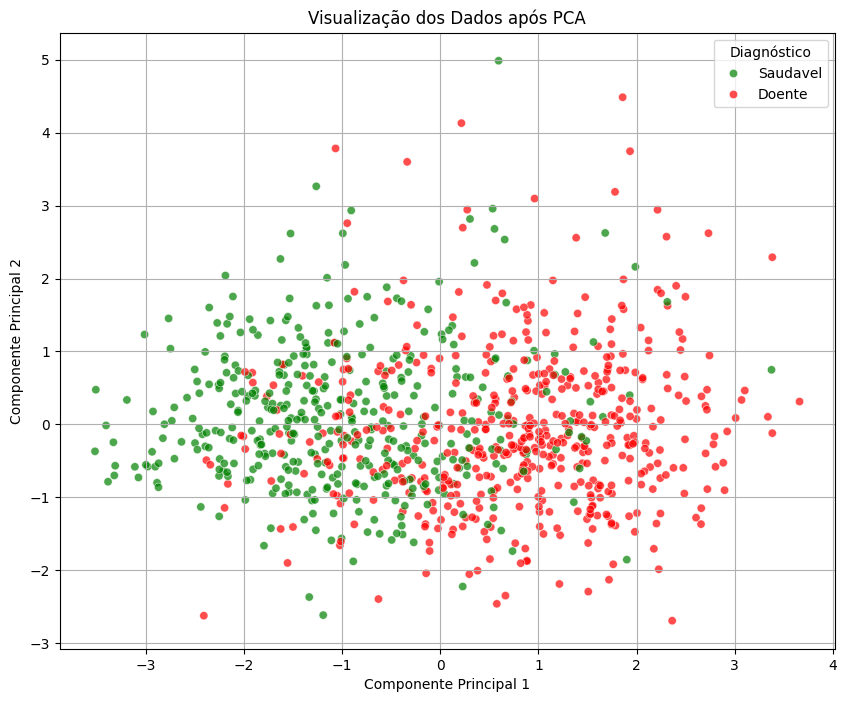

Variância explicada pelos 2 componentes: 37.07%


In [8]:
pca = PCA(n_components=2)

componentes = pca.fit_transform(X)

df_pca = pd.DataFrame(componentes,columns=['Componente 1','Componente 2'])
df_pca['Diagnostico'] = y.map({0:'Saudavel',1:'Doente'})
plt.figure(figsize=(10,8))

sb.scatterplot(
    data=df_pca,
    x='Componente 1',
    y='Componente 2',
    hue='Diagnostico',
    palette={
        'Saudavel':'green',
        'Doente':'red'
    },
    alpha=0.7
)

plt.title('Visualização dos Dados após PCA')

plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')

plt.legend(title='Diagnóstico')
plt.grid(True)
plt.show()

print(
    f"Variância explicada pelos 2 componentes: "
    f"{pca.explained_variance_ratio_.sum()*100:.2f}%"
)

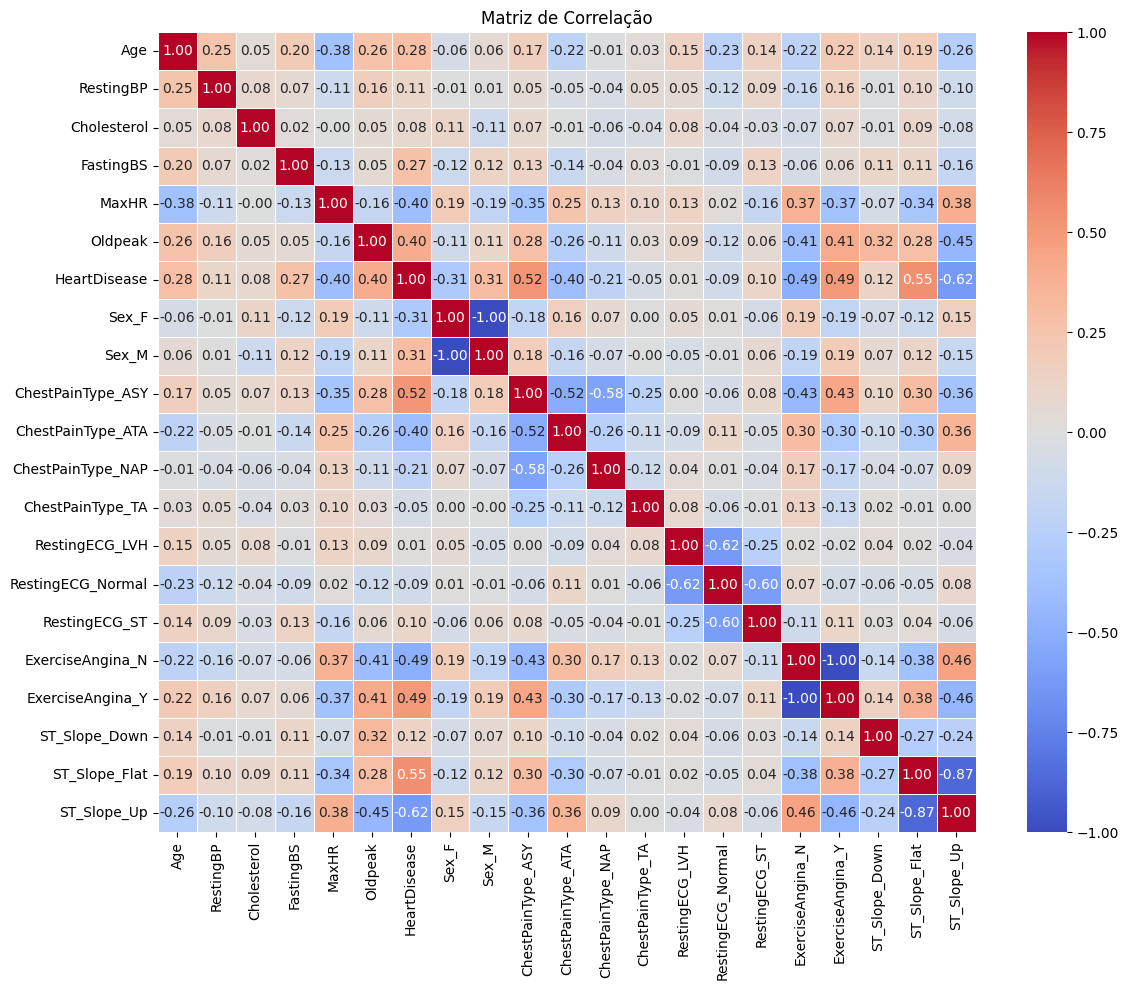

In [9]:
plt.figure(figsize=(12,10))

matriz_corr = heart_df.corr()

sb.heatmap(
    matriz_corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Matriz de Correlação')
plt.tight_layout()
plt.show()

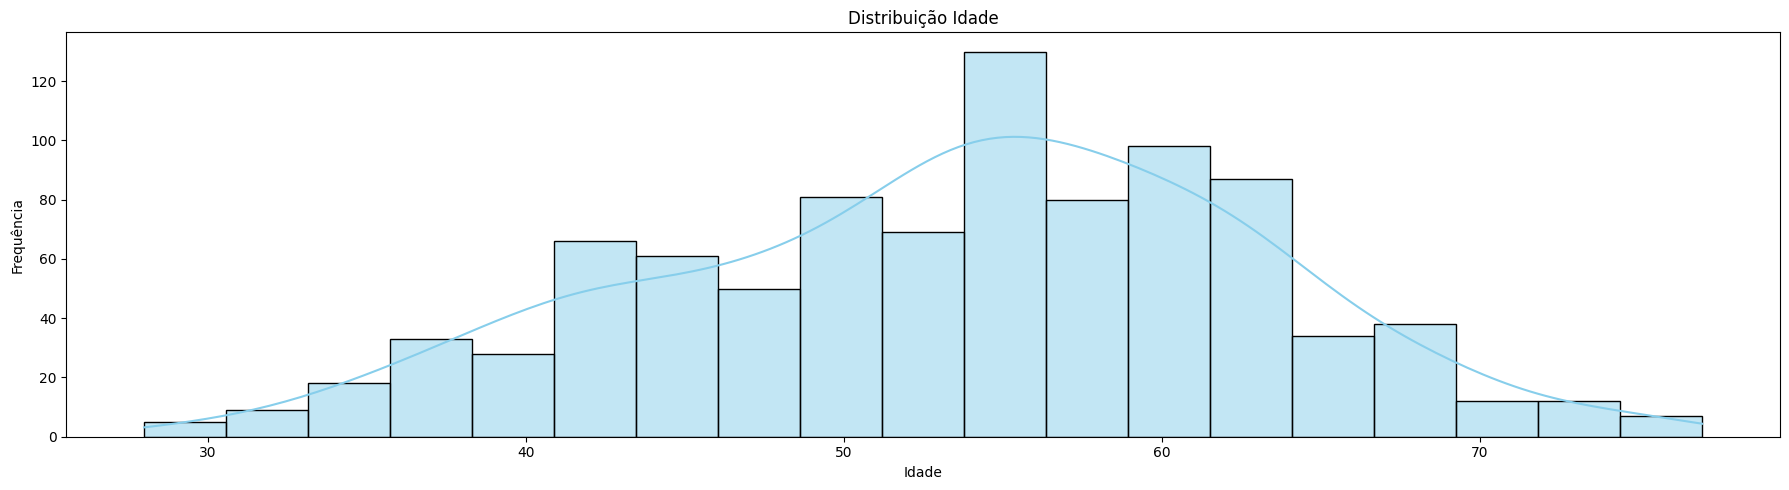

In [10]:
fig, axes = plt.subplots(
    figsize=(18,5)
)

sb.histplot(
    df_visual['Age'],
    kde=True,
    ax=axes,
    color='skyblue'
)

axes.set_title('Distribuição Idade')

axes.set_xlabel('Idade')
axes.set_ylabel('Frequência')

plt.tight_layout()
plt.show()

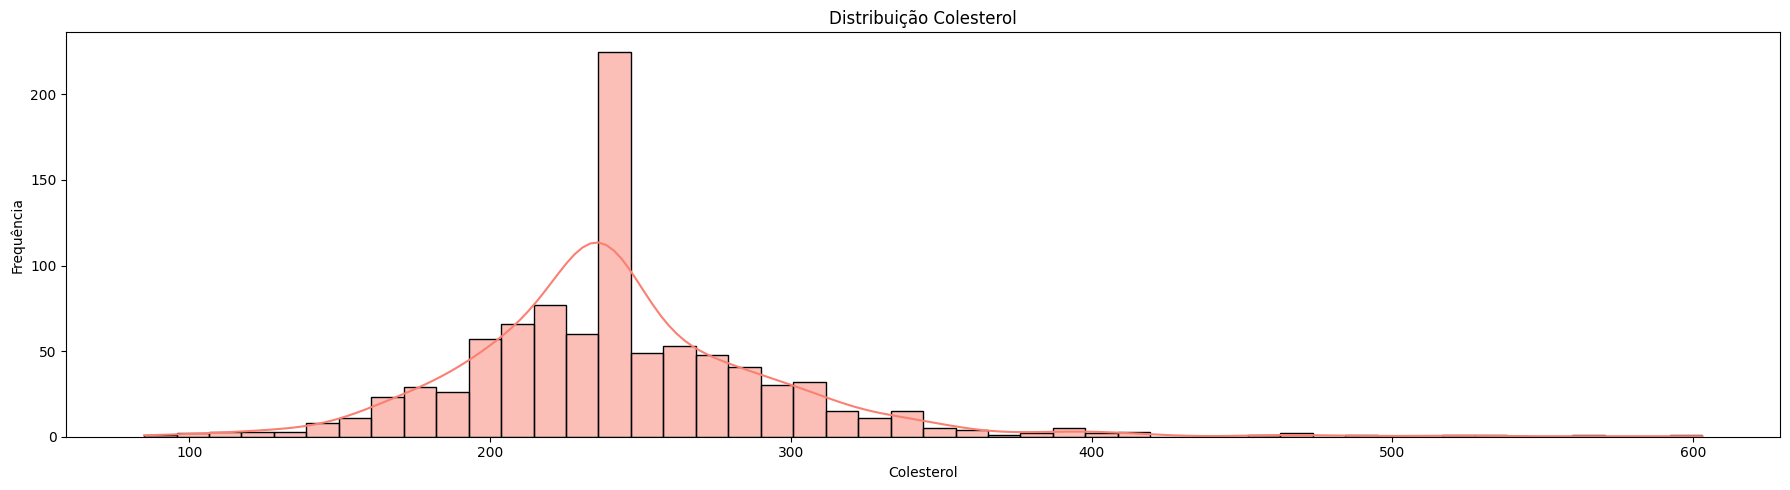

In [11]:
fig, axes = plt.subplots(
    figsize=(18,5)
)

sb.histplot(
    df_visual['Cholesterol'],
    kde=True,
    ax=axes,
    color='salmon'
)

axes.set_title('Distribuição Colesterol')

axes.set_xlabel('Colesterol')
axes.set_ylabel('Frequência')

plt.tight_layout()
plt.show()

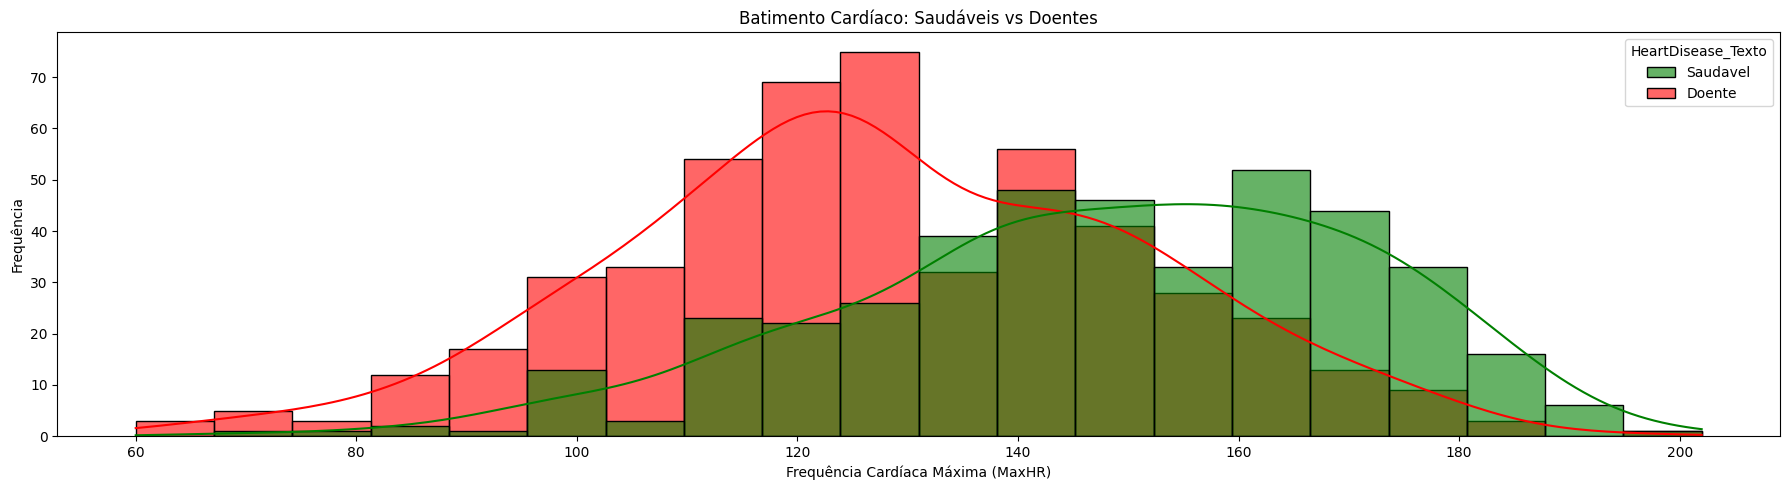

In [12]:
fig, axes = plt.subplots(
    figsize=(18,5)
)

sb.histplot(
    data=df_visual,
    x='MaxHR',
    hue='HeartDisease_Texto',
    kde=True,
    ax=axes,
    palette={
        'Saudavel':'green',
        'Doente':'red'
    },
    multiple='layer',
    alpha=0.6
)

axes.set_title('Batimento Cardíaco: Saudáveis vs Doentes')

axes.set_xlabel('Frequência Cardíaca Máxima (MaxHR)')
axes.set_ylabel('Frequência')

plt.tight_layout()
plt.show()

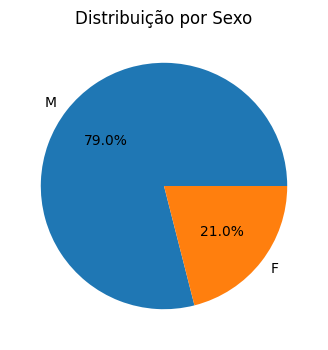

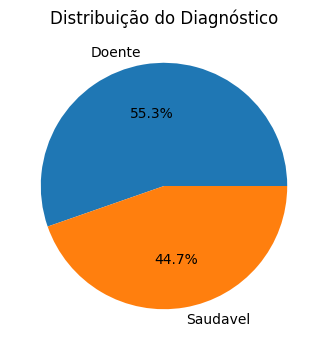

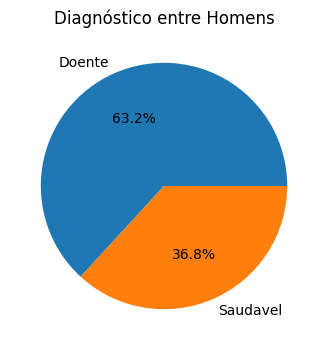

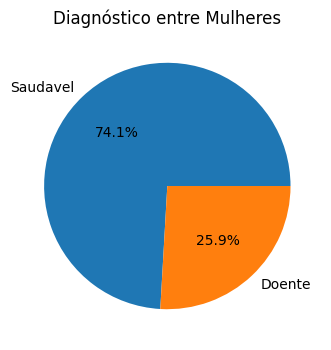

In [13]:
contagem_sexo = df_visual['Sex'].value_counts()

plt.figure(figsize=(4,4))
plt.pie(
    contagem_sexo,
    labels=contagem_sexo.index,
    autopct='%1.1f%%'
)
plt.title('Distribuição por Sexo')

contagem_diag = (
    df_visual['HeartDisease_Texto']
    .value_counts()
)
plt.figure(figsize=(4,4))
plt.pie(
    contagem_diag,
    labels=contagem_diag.index,
    autopct='%1.1f%%'
)
plt.title('Distribuição do Diagnóstico')

homens = (
    df_visual[
        df_visual['Sex'] == 'M'
    ]
)
contagem_homens = (
    homens['HeartDisease_Texto']
    .value_counts()
)
plt.figure(figsize=(4,4))
plt.pie(
    contagem_homens,
    labels=contagem_homens.index,
    autopct='%1.1f%%'
)
plt.title('Diagnóstico entre Homens')

mulheres = (
    df_visual[
        df_visual['Sex'] == 'F'
    ]
)
contagem_mulheres = (
    mulheres['HeartDisease_Texto']
    .value_counts()
)
plt.figure(figsize=(4,4))
plt.pie(
    contagem_mulheres,
    labels=contagem_mulheres.index,
    autopct='%1.1f%%'
)
plt.title('Diagnóstico entre Mulheres')

plt.show()

C:\Users\bruno\AppData\Local\Temp\ipykernel_28236\135639233.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(


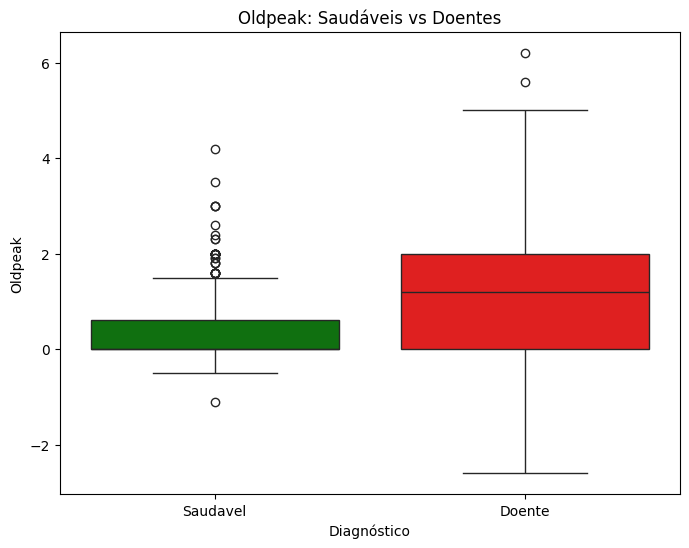

In [14]:
plt.figure(figsize=(8,6))

sb.boxplot(
    data=df_visual,
    x='HeartDisease_Texto',
    y='Oldpeak',
    palette={
        'Saudavel':'green',
        'Doente':'red'
    }
)

plt.title('Oldpeak: Saudáveis vs Doentes')

plt.xlabel('Diagnóstico')
plt.ylabel('Oldpeak')

plt.show()

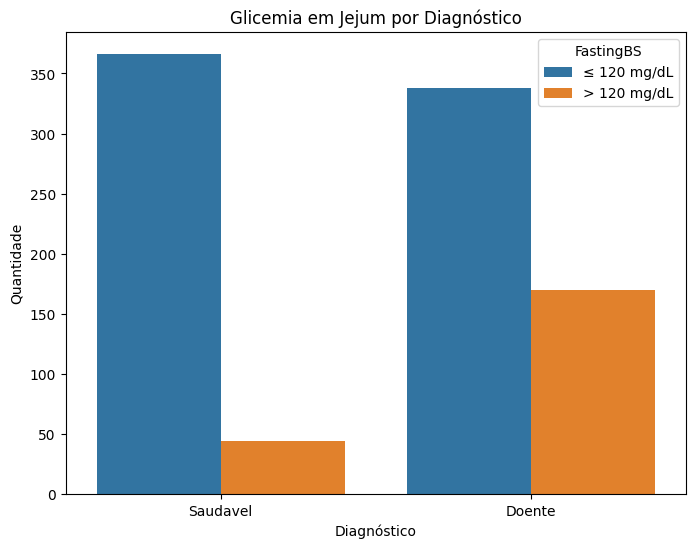

In [15]:
plt.figure(figsize=(8,6))

sb.countplot(
    data=df_visual,
    x='HeartDisease_Texto',
    hue='FastingBS'
)

plt.title('Glicemia em Jejum por Diagnóstico')

plt.xlabel('Diagnóstico')
plt.ylabel('Quantidade')

plt.legend(
    title='FastingBS',
    labels=[
        '≤ 120 mg/dL',
        '> 120 mg/dL'
    ]
)

plt.show()

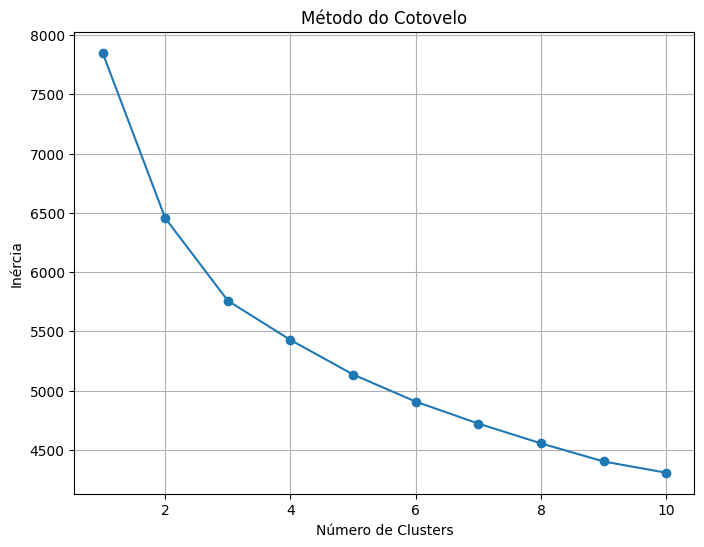

In [16]:
inercias = []

for k in range(1,11):

    kmeans_teste = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans_teste.fit(X)

    inercias.append(
        kmeans_teste.inertia_
    )

plt.figure(figsize=(8,6))

plt.plot(
    range(1,11),
    inercias,
    marker='o'
)

plt.title('Método do Cotovelo')

plt.xlabel('Número de Clusters')
plt.ylabel('Inércia')

plt.grid(True)
plt.show()

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

clusters_kmeans = kmeans.fit_predict(X)

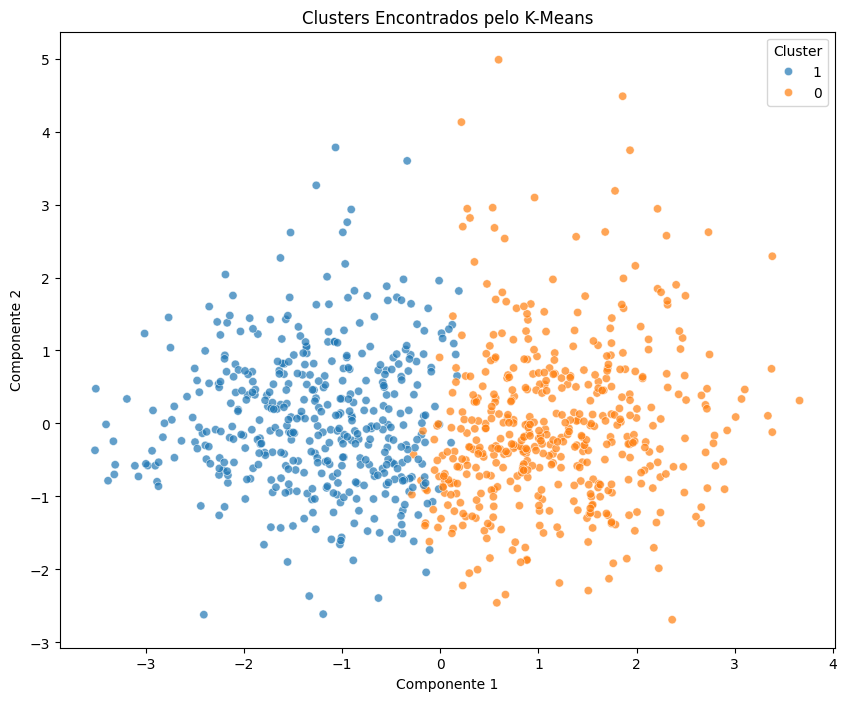

Diagnostico  Doente  Saudavel
Cluster                      
0               402        77
1               106       333


In [17]:
df_kmeans = pd.DataFrame(
    componentes,
    columns=[
        'Componente 1',
        'Componente 2'
    ]
)

df_kmeans['Cluster'] = (clusters_kmeans.astype(str))

plt.figure(figsize=(10,8))

sb.scatterplot(
    data=df_kmeans,
    x='Componente 1',
    y='Componente 2',
    hue='Cluster',
    alpha=0.7
)

plt.title('Clusters Encontrados pelo K-Means')

plt.show()

df_kmeans['Diagnostico'] = y.map({
    0:'Saudavel',
    1:'Doente'
})

print(
    pd.crosstab(
        df_kmeans['Cluster'],
        df_kmeans['Diagnostico']
    )
)

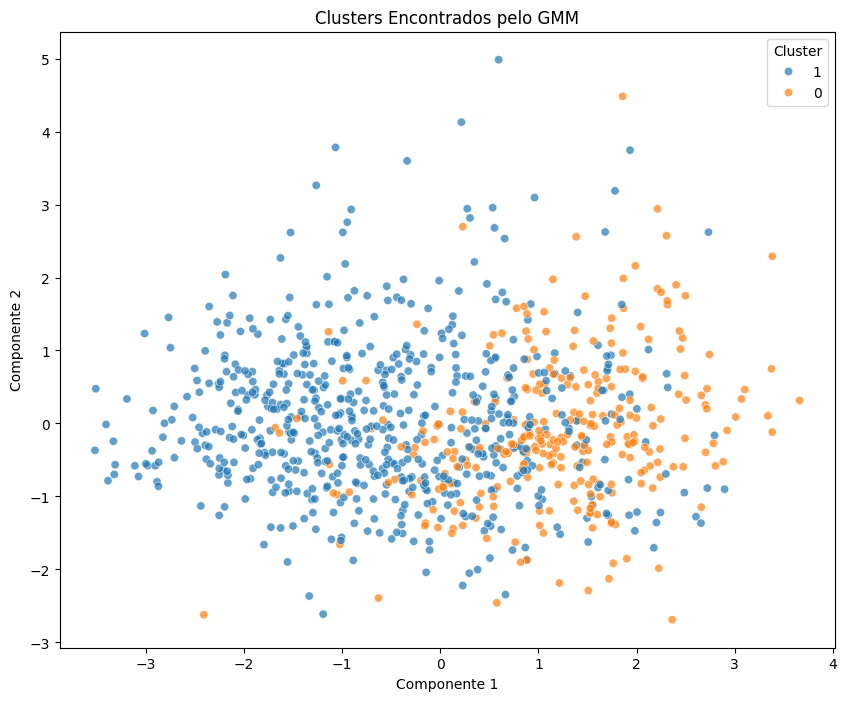

Diagnostico  Doente  Saudavel
Cluster                      
0               261        30
1               247       380


In [18]:
gmm = GaussianMixture(
    n_components=2,
    random_state=42
)

clusters_gmm = gmm.fit_predict(X)

df_gmm = pd.DataFrame(
    componentes,
    columns=[
        'Componente 1',
        'Componente 2'
    ]
)

df_gmm['Cluster'] = (
    clusters_gmm.astype(str)
)

plt.figure(figsize=(10,8))

sb.scatterplot(
    data=df_gmm,
    x='Componente 1',
    y='Componente 2',
    hue='Cluster',
    alpha=0.7
)

plt.title('Clusters Encontrados pelo GMM')

plt.show()

df_gmm['Diagnostico'] = y.map({
    0:'Saudavel',
    1:'Doente'
})

print(
    pd.crosstab(
        df_gmm['Cluster'],
        df_gmm['Diagnostico']
    )
)

In [19]:
def avaliar_modelo(
    modelo,
    nome
):

    resultados = cross_validate(
        modelo,
        X,
        y,
        cv=5,
        scoring=[
            'accuracy',
            'precision',
            'recall',
            'f1'
        ]
    )

    acuracia = resultados['test_accuracy'].mean()*100
    precisao = resultados['test_precision'].mean()*100
    recall = resultados['test_recall'].mean()*100
    f1 = resultados['test_f1'].mean()*100

    print(f'\n----- {nome} -----')
    print(f'Acurácia: {acuracia:.2f}%')
    print(f'Precisão: {precisao:.2f}%')
    print(f'Recall: {recall:.2f}%')
    print(f'F1: {f1:.2f}%')

    return {
        'Acurácia': acuracia,
        'Precisão': precisao,
        'Recall': recall,
        'F1': f1
    }


----- KNN (K=15) -----
Acurácia: 83.76%
Precisão: 84.29%
Recall: 87.59%
F1: 85.60%


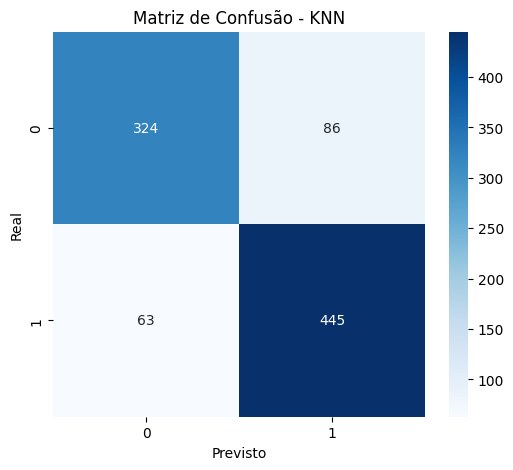

In [20]:
knn_final = KNeighborsClassifier(
    n_neighbors=15
)

avaliar_modelo(
    knn_final,
    'KNN (K=15)'
)

y_pred_knn = cross_val_predict(
    knn_final,
    X,
    y,
    cv=5
)

matriz_knn = confusion_matrix(
    y,
    y_pred_knn
)

plt.figure(figsize=(6,5))

sb.heatmap(
    matriz_knn,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Matriz de Confusão - KNN')

plt.xlabel('Previsto')
plt.ylabel('Real')

plt.show()


----- Árvore de Decisão -----
Acurácia: 79.83%
Precisão: 80.54%
Recall: 86.02%
F1: 82.64%


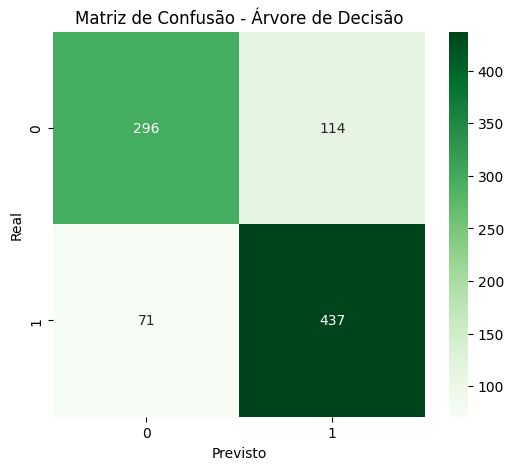

In [21]:
arvore = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

resultado_arvore = avaliar_modelo(
    arvore,
    'Árvore de Decisão'
)

y_pred_arvore = cross_val_predict(
    arvore,
    X,
    y,
    cv=5
)

matriz_arvore = confusion_matrix(
    y,
    y_pred_arvore
)

plt.figure(figsize=(6,5))

sb.heatmap(
    matriz_arvore,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title(
    'Matriz de Confusão - Árvore de Decisão')

plt.xlabel('Previsto')
plt.ylabel('Real')

plt.show()

In [22]:
from sklearn.tree import export_text

arvore.fit(X, y)

caminho_da_arvore = export_text(
    arvore, 
    feature_names=list(X.columns)
)

print(caminho_da_arvore)

|--- ST_Slope_Up <= 0.50
|   |--- ChestPainType_ASY <= 0.50
|   |   |--- Sex_F <= 0.50
|   |   |   |--- MaxHR <= -0.01
|   |   |   |   |--- class: 1
|   |   |   |--- MaxHR >  -0.01
|   |   |   |   |--- class: 1
|   |   |--- Sex_F >  0.50
|   |   |   |--- Cholesterol <= -0.14
|   |   |   |   |--- class: 0
|   |   |   |--- Cholesterol >  -0.14
|   |   |   |   |--- class: 0
|   |--- ChestPainType_ASY >  0.50
|   |   |--- Sex_F <= 0.50
|   |   |   |--- RestingBP <= -2.51
|   |   |   |   |--- class: 0
|   |   |   |--- RestingBP >  -2.51
|   |   |   |   |--- class: 1
|   |   |--- Sex_F >  0.50
|   |   |   |--- Oldpeak <= 0.72
|   |   |   |   |--- class: 1
|   |   |   |--- Oldpeak >  0.72
|   |   |   |   |--- class: 1
|--- ST_Slope_Up >  0.50
|   |--- ChestPainType_ASY <= 0.50
|   |   |--- Oldpeak <= 1.23
|   |   |   |--- RestingBP <= 3.17
|   |   |   |   |--- class: 0
|   |   |   |--- RestingBP >  3.17
|   |   |   |   |--- class: 1
|   |   |--- Oldpeak >  1.23
|   |   |   |--- class: 1
|   |


----- SVM -----
Acurácia: 82.89%
Precisão: 84.11%
Recall: 86.21%
F1: 84.77%


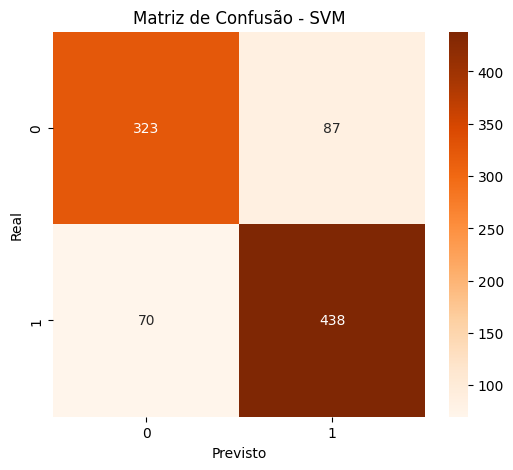

In [23]:
svm = SVC(
    kernel='rbf',
    C=1.0,
    random_state=42
)

resultado_svm = avaliar_modelo(
    svm,
    'SVM'
)

y_pred_svm = cross_val_predict(
    svm,
    X,
    y,
    cv=5
)

matriz_svm = confusion_matrix(
    y,
    y_pred_svm
)

plt.figure(figsize=(6,5))

sb.heatmap(
    matriz_svm,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title('Matriz de Confusão - SVM')

plt.xlabel('Previsto')
plt.ylabel('Real')

plt.show()


----- Rede Neural -----
Acurácia: 78.86%
Precisão: 81.44%
Recall: 81.88%
F1: 81.14%

----- Rede Neural -----
Acurácia: 78.86%
Precisão: 81.44%
Recall: 81.88%
F1: 81.14%


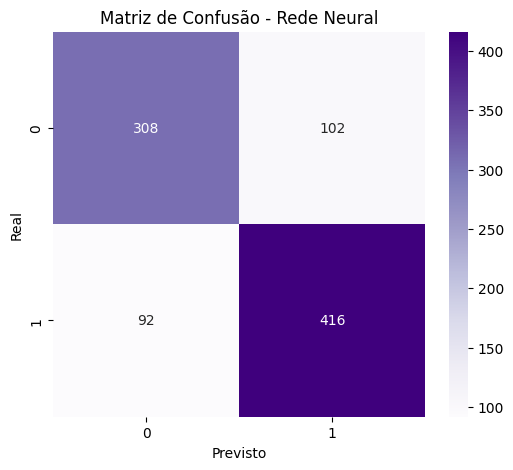

In [24]:
rede = MLPClassifier(
    hidden_layer_sizes=(20,10),
    max_iter=3000,
    random_state=42
)

resultado_rede = avaliar_modelo(
    rede,
    'Rede Neural'
)

resultado_rede = avaliar_modelo(rede,'Rede Neural')

y_pred_rede = cross_val_predict(
    rede,
    X,
    y,
    cv=5
)

matriz_rede = confusion_matrix(
    y,
    y_pred_rede
)

plt.figure(figsize=(6,5))

sb.heatmap(
    matriz_rede,
    annot=True,
    fmt='d',
    cmap='Purples'
)

plt.title(
    'Matriz de Confusão - Rede Neural'
)

plt.xlabel('Previsto')
plt.ylabel('Real')

plt.show()